# Prototype IRRBB and ALM Analytics Engine

This notebook is a technically grounded **prototype**, not a production regulatory system. It connects:

1. **Continuously compounded zero-coupon curves** from the Federal Reserve's Gürkaynak–Sack–Wright (`SVENY*`) dataset
2. A numerically stable **classic 3-parameter Nelson–Siegel (NS)** representation and PCA cross-check (reduced from the original 4-parameter Nelson–Siegel–Svensson: at this notebook's 30y-max tenor grid, the fitted second decay parameter lambda2 (~15.5y) made the slope and second curvature regressors nearly collinear — design condition number ~341, corr(slope, curvature2) = -0.98 — which broke the textbook correspondence between the level parameter beta0 and the PCA level factor. Dropping the second curvature term removes that collinearity entirely.)
3. A **reconciled illustrative banking book** in which assets = liabilities + Tier 1 capital
4. Behavioural **non-maturing deposits (NMDs)** integrated directly into EVE and NII
5. Full-revaluation **ΔEVE** under the six BCBS scenarios, using the shock table effective from 1 January 2026
6. The supervisory **maximum adverse ΔEVE / Tier 1 capital** outlier metric
7. A constant-balance-sheet, 12-month **ΔNII** model with product-specific repricing betas
8. Validation checks and an optional, explicitly separate DV01-neutral curve-trade appendix

### Scope and units

- Currency: **USD** by default; a TRY shock configuration is also included.
- Monetary amounts: **millions**.
- Curve observations: **percentage points**; for example, `4.25` means 4.25%.
- Shock configuration: **basis points**.
- Discounting: continuously compounded zero rates, so $DF(t)=e^{-z(t)t}$.

### Primary references

- Federal Reserve nominal zero-coupon curve: https://www.federalreserve.gov/data/nominal-yield-curve.htm
- BCBS 2024 recalibration, effective 1 January 2026: https://www.bis.org/bcbs/publ/d578.htm
- Basel Framework IRRBB chapter and 15% Tier 1 outlier test: https://www.bis.org/basel_framework/chapter/SRP/31.htm

In [1]:
from __future__ import annotations

import io
import urllib.request
import requests
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
CURRENCY = "USD"
ZERO_TENORS = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30], dtype=float)
ZERO_LABELS = [f"{int(t)}Y" for t in ZERO_TENORS]
ZERO_COLUMNS = [f"SVENY{int(t):02d}" for t in ZERO_TENORS]
FED_ZERO_CURVE_CSV = "https://www.federalreserve.gov/data/yield-curve-tables/feds200628.csv"
LOOKBACK_YEARS = 3

# BCBS d578 / Basel Framework table effective 1 January 2026, in basis points.
SHOCK_CONFIG_BP = {
    "USD": {"parallel": 200.0, "short": 300.0, "long": 225.0},
    "TRY": {"parallel": 400.0, "short": 500.0, "long": 300.0},
}
SHOCK_DECAY_YEARS = 4.0
POST_SHOCK_RATE_FLOOR_PCT = None  # Set to 0.0 only if the applicable supervisor requires a zero floor.

TIER1_CAPITAL_MM = 150.0
OUTLIER_LIMIT = 0.15
NII_HORIZON_YEARS = 1.0

assert CURRENCY in SHOCK_CONFIG_BP

## 1. Zero-coupon curve acquisition

The original version used Treasury constant-maturity `DGS*` yields as though they were continuously compounded zero rates. This revision instead attempts to load the Federal Reserve's `SVENY*` series, which are explicitly **continuously compounded zero-coupon yields**.

The official CSV contains a metadata preamble, so the loader locates the header dynamically. If the network is unavailable, the notebook falls back to a clearly labelled synthetic NSS-consistent zero curve.

In [2]:
def nss_loadings(tau, lambda1):
    """Classic 3-parameter Nelson-Siegel design matrix (reduced from 4-parameter
    Svensson). tau and lambda1 are measured in years.

    Dropping the second curvature term (and its own decay parameter lambda2)
    removes the near-collinear regressor that, at the fitted Svensson lambda2
    (~15.5y) on a 30y-max tenor grid, made beta0/beta1/beta3 individually
    unstable day to day (design condition number ~341) even though the FITTED
    curve was accurate. With only one decay parameter there is nothing left
    for lambda2 to compete with, and beta0 recovers its textbook role as the
    level factor.
    """
    tau = np.asarray(tau, dtype=float)
    tau_safe = np.maximum(tau, 1e-8)

    x1 = tau_safe / lambda1
    level = np.ones_like(tau_safe)
    slope = -np.expm1(-x1) / x1
    curvature = slope - np.exp(-x1)
    return np.column_stack([level, slope, curvature])


def nss_zero_rate_pct(beta, tau, lambda1):
    beta = np.asarray(beta, dtype=float)
    return nss_loadings(np.atleast_1d(tau), lambda1) @ beta


def build_synthetic_zero_panel(n_days=750, tenors=ZERO_TENORS, seed=7):
    """Synthetic continuously compounded Nelson-Siegel zero rates in percentage points."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n_days)

    def ou_path(x0, mu, theta, sigma, n):
        x = np.empty(n)
        x[0] = x0
        for i in range(1, n):
            x[i] = x[i - 1] + theta * (mu - x[i - 1]) + sigma * rng.standard_normal()
        return x

    beta = np.column_stack([
        ou_path(4.0, 4.0, 0.02, 0.055, n_days),
        ou_path(-1.0, -1.0, 0.03, 0.030, n_days),
        ou_path(0.6, 0.6, 0.03, 0.025, n_days),
    ])
    lambda1 = 1.5
    design = nss_loadings(tenors, lambda1)
    panel = beta @ design.T + rng.normal(0.0, 0.008, size=(n_days, len(tenors)))
    return pd.DataFrame(panel, index=dates, columns=ZERO_LABELS).clip(lower=0.01)


def load_federal_reserve_zero_panel(
    url=FED_ZERO_CURVE_CSV,
    lookback_years=LOOKBACK_YEARS,
):
    landing_url = (
        "https://www.federalreserve.gov/data/"
        "nominal-yield-curve.htm"
    )

    session = requests.Session()

    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/126.0 Safari/537.36"
        ),
        "Accept": (
            "text/html,application/xhtml+xml,application/xml;"
            "q=0.9,text/csv;q=0.8,*/*;q=0.7"
        ),
        "Accept-Language": "en-US,en;q=0.9",
        "Referer": landing_url,
    })

    landing_response = session.get(
        landing_url,
        timeout=30,
    )
    landing_response.raise_for_status()

    csv_response = session.get(
        url,
        timeout=60,
    )
    csv_response.raise_for_status()

    text = csv_response.content.decode("utf-8-sig")
    lines = text.splitlines()

    header_idx = next(
        i for i, line in enumerate(lines)
        if line.startswith("Date,")
    )

    raw = pd.read_csv(
        io.StringIO("\n".join(lines[header_idx:]))
    )

    raw["Date"] = pd.to_datetime(
        raw["Date"],
        errors="coerce",
    )

    missing = sorted(
        set(ZERO_COLUMNS) - set(raw.columns)
    )

    if missing:
        raise KeyError(
            f"Missing expected SVENY columns: {missing}"
        )

    panel = (
        raw
        .set_index("Date")[ZERO_COLUMNS]
        .apply(pd.to_numeric, errors="coerce")
        .replace(-999.99, np.nan)
    )

    panel.columns = ZERO_LABELS

    cutoff = (
        panel.index.max()
        - pd.DateOffset(years=lookback_years)
    )

    panel = (
        panel
        .loc[panel.index >= cutoff]
        .sort_index()
        .dropna(how="all")
        .interpolate(limit_direction="both")
        .dropna()
    )

    if len(panel) < 100:
        raise ValueError(
            f"Curve panel is too short: {len(panel)} observations."
        )

    return panel


try:
    zero_yields = load_federal_reserve_zero_panel()
    DATA_SOURCE = "Federal Reserve GSW SVENY zero-coupon curve (live)"
except Exception as exc:
    print(f"Live Federal Reserve pull unavailable ({type(exc).__name__}: {exc}).")
    print("Using a SYNTHETIC continuously compounded zero-coupon panel instead.")
    zero_yields = build_synthetic_zero_panel()
    DATA_SOURCE = "SYNTHETIC NSS zero-coupon panel — NOT market data"

print(f"Data source : {DATA_SOURCE}")
print(f"Shape       : {zero_yields.shape}")
print(f"Date range  : {zero_yields.index.min().date()} -> {zero_yields.index.max().date()}")
display(zero_yields.tail())


Data source : Federal Reserve GSW SVENY zero-coupon curve (live)
Shape       : (751, 9)
Date range  : 2023-07-17 -> 2026-07-17


,1Y,2Y,3Y,5Y,7Y,10Y,15Y,20Y,30Y
Date,,,,,,,,,
2026-07-13,4.1505,4.1898,4.2387,4.3559,4.4877,4.6894,4.9831,5.1821,5.2740
2026-07-14,4.0700,4.1164,4.1716,4.3001,4.4411,4.6538,4.9595,5.1651,5.2616
2026-07-15,4.0208,4.0640,4.1179,4.2480,4.3944,4.6181,4.9424,5.1606,5.2620
2026-07-16,4.0429,4.0871,4.1416,4.2718,4.4173,4.6391,4.9601,5.1763,5.2781
2026-07-17,4.0611,4.1005,4.1503,4.2716,4.4091,4.6212,4.9323,5.1455,5.2541


## 2. Stable NSS representation

Conditional on $\lambda_1$ and $\lambda_2$, NSS is linear in the four beta coefficients. Estimating all six parameters independently every day can produce excellent curve fits but unstable, economically meaningless beta/lambda jumps.

This implementation therefore:

1. Estimates **one global pair** $\lambda_1<\lambda_2$ over the panel using multiple starting values.
2. Solves the four daily beta coefficients by linear least squares.
3. Checks optimiser success, the design-matrix condition number and daily fit errors.

This is a representation of the zero curve; it does not convert par yields into zero rates because the input is already `SVENY` zero-coupon data.

In [3]:
def panel_fit_for_lambda(panel_values, tenors, lambda1):
    design = nss_loadings(tenors, lambda1)
    betas = np.linalg.lstsq(design, panel_values.T, rcond=None)[0].T
    fitted = betas @ design.T
    return betas, fitted, np.linalg.cond(design)


def calibrate_global_lambda(panel, tenors):
    # Sampling every fifth date is enough for shape calibration and reduces runtime on long panels.
    sampled = panel.iloc[::5].values

    def objective(x):
        lambda1 = np.exp(x[0])
        betas, fitted, condition_number = panel_fit_for_lambda(sampled, tenors, lambda1)
        mse = np.mean((fitted - sampled) ** 2)
        # A mild numerical penalty discourages nearly collinear loading matrices.
        condition_penalty = 1e-8 * max(condition_number - 1_000.0, 0.0) ** 2
        return mse + condition_penalty

    starts = [0.5, 1.0, 1.5, 2.5, 4.0]
    results = []
    bounds = [(np.log(0.10), np.log(10.0))]

    for lambda1_start in starts:
        x0 = np.log([lambda1_start])
        result = minimize(objective, x0=x0, method="L-BFGS-B", bounds=bounds)
        results.append(result)

    successful = [r for r in results if r.success and np.isfinite(r.fun)]
    if not successful:
        messages = [r.message for r in results]
        raise RuntimeError(f"Global Nelson-Siegel lambda calibration failed: {messages}")

    best = min(successful, key=lambda r: r.fun)
    lambda1 = np.exp(best.x[0])
    return lambda1, best


lambda1_hat, lambda_result = calibrate_global_lambda(zero_yields, ZERO_TENORS)
beta_values, fitted_values, design_condition = panel_fit_for_lambda(
    zero_yields.values, ZERO_TENORS, lambda1_hat
)

nss_params = pd.DataFrame(
    beta_values,
    index=zero_yields.index,
    columns=["beta0", "beta1", "beta2"],
)
nss_params["lambda1"] = lambda1_hat

fit_errors = fitted_values - zero_yields.values
rmse_bp = np.sqrt(np.mean(fit_errors**2, axis=1)) * 100.0
max_abs_error_bp = np.max(np.abs(fit_errors), axis=1) * 100.0

print(f"Optimizer success       : {lambda_result.success}")
print(f"Global lambda1          : {lambda1_hat:.4f} years")
print(f"Design condition number : {design_condition:,.1f}")
print(f"Mean daily RMSE         : {rmse_bp.mean():.3f} bp")
print(f"95th pct daily RMSE     : {np.quantile(rmse_bp, 0.95):.3f} bp")
print(f"Maximum point error     : {max_abs_error_bp.max():.3f} bp")
display(nss_params.tail())


Optimizer success       : True
Global lambda1          : 2.4138 years
Design condition number : 17.2
Mean daily RMSE         : 3.290 bp
95th pct daily RMSE     : 5.999 bp
Maximum point error     : 16.956 bp


,beta0,beta1,beta2,lambda1
Date,,,,
2026-07-13,5.561501,-1.219694,-2.364230,2.413774
2026-07-14,5.562087,-1.304681,-2.433402,2.413774
2026-07-15,5.580242,-1.349499,-2.608646,2.413774
2026-07-16,5.592729,-1.344014,-2.578655,2.413774
2026-07-17,5.553958,-1.279306,-2.546379,2.413774


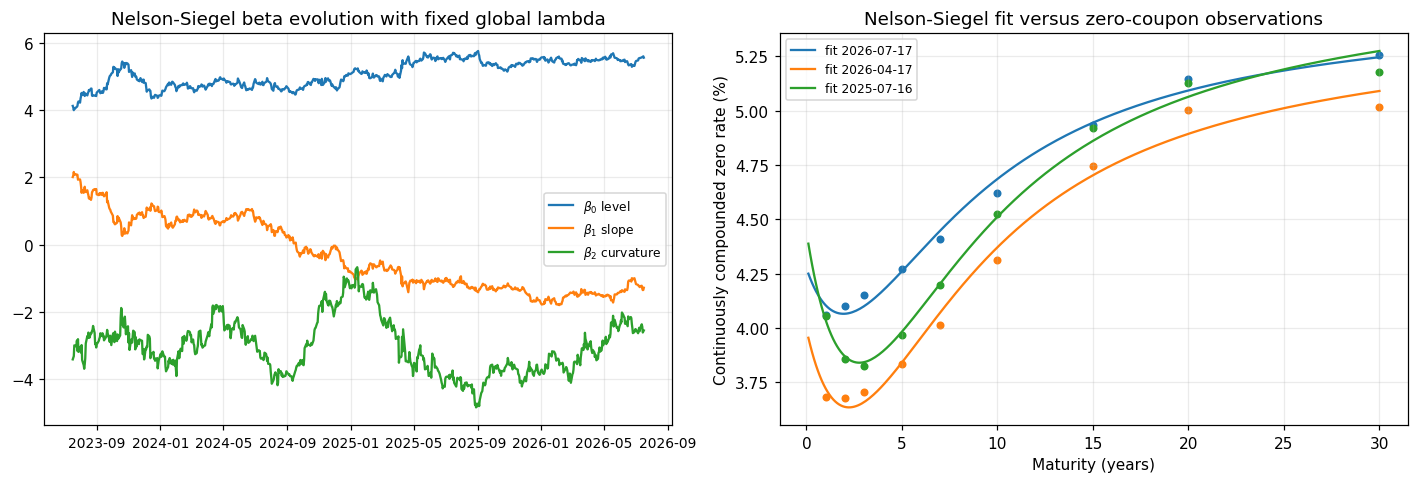

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for column, label in {
    "beta0": r"$\beta_0$ level",
    "beta1": r"$\beta_1$ slope",
    "beta2": r"$\beta_2$ curvature",
}.items():
    axes[0].plot(nss_params.index, nss_params[column], label=label)
axes[0].set_title("Nelson-Siegel beta evolution with fixed global lambda")
axes[0].legend(fontsize=8)

fine_tau = np.linspace(0.10, 30.0, 300)
sample_positions = [-1, -63, -252] if len(zero_yields) > 252 else [-1]
for pos in sample_positions:
    date = zero_yields.index[pos]
    beta = nss_params.loc[date, ["beta0", "beta1", "beta2"]].values
    axes[1].plot(
        fine_tau,
        nss_zero_rate_pct(beta, fine_tau, lambda1_hat),
        label=f"fit {date.date()}",
    )
    axes[1].scatter(ZERO_TENORS, zero_yields.loc[date].values, s=18)
axes[1].set_title("Nelson-Siegel fit versus zero-coupon observations")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Continuously compounded zero rate (%)")
axes[1].legend(fontsize=8)
axes[0].tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.show()


## 3. PCA cross-check

PCA is applied to daily **changes** in zero rates. The first three components should broadly resemble level, slope and curvature factors. Component signs are arbitrary.

Explained variance ratio: [0.839  0.1167 0.0308]
Cumulative PC1-PC3     : 0.9865


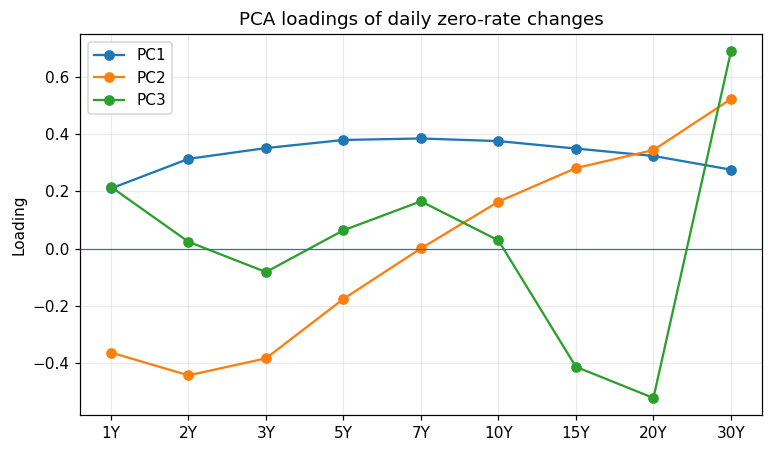

corr(PC1 score, Δbeta0): +0.672 (sign is arbitrary)
Reduced to 3-parameter Nelson-Siegel: this correlation should now sit
close to the textbook range (>0.9), since beta0 no longer competes
with a near-collinear second curvature term for the same variation.


In [5]:
daily_changes = zero_yields.diff().dropna()
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(daily_changes.values)
explained = pca.explained_variance_ratio_

print("Explained variance ratio:", np.round(explained, 4))
print(f"Cumulative PC1-PC3     : {explained.sum():.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, label in enumerate(["PC1", "PC2", "PC3"]):
    ax.plot(ZERO_LABELS, pca.components_[i], marker="o", label=label)
ax.axhline(0.0, linewidth=0.8)
ax.set_title("PCA loadings of daily zero-rate changes")
ax.set_ylabel("Loading")
ax.legend()
plt.show()

beta0_change = nss_params["beta0"].diff().reindex(daily_changes.index)
level_corr = np.corrcoef(pca_scores[:, 0], beta0_change.values)[0, 1]
print(f"corr(PC1 score, Δbeta0): {level_corr:+.3f} (sign is arbitrary)")
print("Reduced to 3-parameter Nelson-Siegel: this correlation should now sit")
print("close to the textbook range (>0.9), since beta0 no longer competes")
print("with a near-collinear second curvature term for the same variation.")


## 4. Behavioural NMD model and replicating portfolio

The NMD history remains illustrative, but its output is no longer disconnected from the risk engine. The current NMD balance is split into:

- **Non-core**: assigned to an overnight/one-month behavioural horizon.
- **Core**: allocated to a 1–5 year replicating ladder.

The resulting NMD rows are inserted into the liability book used by both EVE and NII. The core floor method is intentionally transparent rather than presented as a universal regulatory calibration. A 90% governance cap prevents an implausibly high core share in the synthetic history.

Current NMD balance      : 650.00 mm
Core balance             : 585.00 mm (90.0%)
Non-core balance         : 65.00 mm (10.0%)
Core blended FTP         : 4.140%
NMD weighted EVE horizon : 2.71 years


,behavioural_horizon_y,notional_mm,zero_curve_ftp_pct
0,1.0,117.0,4.104435
1,2.0,117.0,4.064894
2,3.0,117.0,4.098825
3,4.0,117.0,4.171120
4,5.0,117.0,4.260655


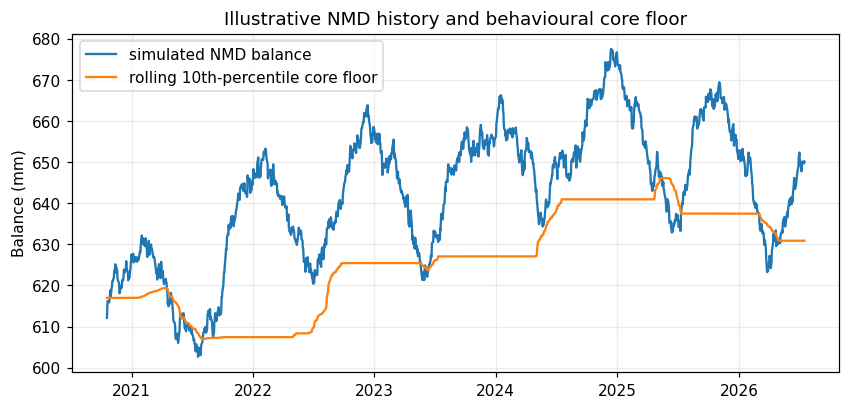

In [6]:
def simulate_nmd_balance(n_days=1500, target_current_mm=650.0, seed=11):
    rng = np.random.default_rng(seed)
    x = np.arange(n_days)
    raw = (
        500.0
        + 0.018 * x
        + 14.0 * np.sin(2.0 * np.pi * x / 252.0)
        + np.cumsum(rng.normal(0.0, 1.0, n_days))
    )
    raw = np.maximum(raw, 50.0)
    raw *= target_current_mm / raw[-1]
    dates = pd.bdate_range(end=zero_yields.index[-1], periods=n_days)
    return pd.Series(raw, index=dates, name="nmd_balance_mm")


def core_noncore_split(balance, window=252, core_quantile=0.10, core_fraction_cap=0.90):
    floor = balance.rolling(window, min_periods=window // 4).quantile(core_quantile).bfill()
    governance_cap = core_fraction_cap * float(balance.iloc[-1])
    core = float(min(floor.iloc[-1], governance_cap, balance.iloc[-1]))
    noncore = float(balance.iloc[-1] - core)
    return core, noncore, floor


nmd_balance = simulate_nmd_balance()
nmd_core_mm, nmd_noncore_mm, nmd_floor = core_noncore_split(nmd_balance)
CURRENT_NMD_MM = float(nmd_balance.iloc[-1])

current_beta = nss_params.iloc[-1][["beta0", "beta1", "beta2"]].values

def base_zero_rate_pct(tau):
    return nss_zero_rate_pct(current_beta, tau, lambda1_hat)


core_tenors = np.array([1, 2, 3, 4, 5], dtype=float)
core_weights = np.repeat(1.0 / len(core_tenors), len(core_tenors))
core_notionals = nmd_core_mm * core_weights
core_ftp_rates_pct = base_zero_rate_pct(core_tenors)
blended_ftp_pct = np.average(core_ftp_rates_pct, weights=core_weights)
effective_nmd_horizon = (
    nmd_noncore_mm * (1.0 / 12.0) + np.sum(core_notionals * core_tenors)
) / CURRENT_NMD_MM

print(f"Current NMD balance      : {CURRENT_NMD_MM:,.2f} mm")
print(f"Core balance             : {nmd_core_mm:,.2f} mm ({nmd_core_mm/CURRENT_NMD_MM:.1%})")
print(f"Non-core balance         : {nmd_noncore_mm:,.2f} mm ({nmd_noncore_mm/CURRENT_NMD_MM:.1%})")
print(f"Core blended FTP         : {blended_ftp_pct:.3f}%")
print(f"NMD weighted EVE horizon : {effective_nmd_horizon:.2f} years")

nmd_ladder_display = pd.DataFrame({
    "behavioural_horizon_y": core_tenors,
    "notional_mm": core_notionals,
    "zero_curve_ftp_pct": core_ftp_rates_pct,
})
display(nmd_ladder_display)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(nmd_balance.index, nmd_balance, label="simulated NMD balance")
ax.plot(nmd_floor.index, nmd_floor, label="rolling 10th-percentile core floor")
ax.set_title("Illustrative NMD history and behavioural core floor")
ax.set_ylabel("Balance (mm)")
ax.legend()
plt.show()


## 5. Reconciled illustrative banking book

The instrument schema separates two horizons:

- `eve_horizon_y`: the horizon at which principal is treated as repricing/maturing for EVE. For floating-rate instruments, this is the next reset date rather than legal maturity.
- `nii_repricing_y`: the next repricing point used in the 12-month earnings simulation.

The book is deliberately constructed so that:

\[
\text{Assets}=\text{Interest-bearing liabilities}+\text{Tier 1 capital}.
\]

Own equity is used as the supervisory denominator but is **not** discounted as an interest-bearing liability in the EVE calculation.

In [7]:
def instrument_row(
    instrument_id, side, product, notional_mm, coupon_rate, legal_maturity_y,
    eve_horizon_y, nii_repricing_y, rate_type, nii_beta_up=1.0, nii_beta_down=1.0,
):
    return {
        "instrument_id": instrument_id,
        "side": side,
        "product": product,
        "currency": CURRENCY,
        "notional_mm": float(notional_mm),
        "coupon_rate": float(coupon_rate),        # decimal, eg 0.045 = 4.5%
        "legal_maturity_y": float(legal_maturity_y),
        "eve_horizon_y": float(eve_horizon_y),
        "nii_repricing_y": float(nii_repricing_y),
        "rate_type": rate_type,
        "nii_beta_up": float(nii_beta_up),
        "nii_beta_down": float(nii_beta_down),
    }


asset_rows = [
    instrument_row("A01", "asset", "HQLA floating",       100, 0.041, 0.5, 0.25, 0.25, "floating"),
    instrument_row("A02", "asset", "Corporate floating", 200, 0.052, 3.0, 0.25, 0.25, "floating"),
    instrument_row("A03", "asset", "SME floating",       150, 0.056, 5.0, 0.50, 0.50, "floating"),
    instrument_row("A04", "asset", "Retail floating",    250, 0.051, 3.0, 0.50, 0.50, "floating"),
    instrument_row("A05", "asset", "Mortgage floating",  300, 0.053, 5.0, 0.75, 0.75, "floating"),
    instrument_row("A06", "asset", "Securities fixed",   220, 0.049, 2.0, 2.00, 2.00, "fixed"),
    instrument_row("A07", "asset", "Mortgage fixed",     180, 0.054, 5.0, 5.00, 5.00, "fixed"),
    instrument_row("A08", "asset", "Corporate fixed",    100, 0.055, 15.0, 15.0, 15.0, "fixed"),
]

wholesale_liability_rows = [
    instrument_row("L01", "liability", "Money-market funding", 120, 0.037, 0.25, 0.25, 0.25, "floating"),
    instrument_row("L02", "liability", "Wholesale floating",  150, 0.039, 1.00, 0.25, 0.25, "floating"),
    instrument_row("L03", "liability", "Wholesale floating",  130, 0.041, 2.00, 0.50, 0.50, "floating"),
    instrument_row("L04", "liability", "Term funding fixed",  120, 0.043, 2.00, 2.00, 2.00, "fixed"),
    instrument_row("L05", "liability", "Term funding fixed",  100, 0.044, 3.00, 3.00, 3.00, "fixed"),
    instrument_row("L06", "liability", "Term funding fixed",   80, 0.046, 5.00, 5.00, 5.00, "fixed"),
]

# Illustrative customer rate. NMD repricing is immediate for NII but only partial through beta.
NMD_CUSTOMER_RATE = 0.018
nmd_rows = [
    instrument_row(
        "NMD00", "liability", "NMD non-core", nmd_noncore_mm, NMD_CUSTOMER_RATE,
        0.10, 1.0/12.0, 0.0, "behavioural", nii_beta_up=0.35, nii_beta_down=0.20,
    )
]
for i, (tenor, notional) in enumerate(zip(core_tenors, core_notionals), start=1):
    nmd_rows.append(
        instrument_row(
            f"NMD{i:02d}", "liability", "NMD core ladder", notional, NMD_CUSTOMER_RATE,
            tenor, tenor, 0.0, "behavioural", nii_beta_up=0.35, nii_beta_down=0.20,
        )
    )

banking_book = pd.DataFrame(asset_rows + wholesale_liability_rows + nmd_rows)

book_totals = banking_book.groupby("side")["notional_mm"].sum()
book_assets_mm = float(book_totals["asset"])
book_liabilities_mm = float(book_totals["liability"])
book_equity_mm = book_assets_mm - book_liabilities_mm

reconciliation = pd.Series({
    "Assets": book_assets_mm,
    "Wholesale liabilities": sum(r["notional_mm"] for r in wholesale_liability_rows),
    "NMD liabilities": CURRENT_NMD_MM,
    "Total interest-bearing liabilities": book_liabilities_mm,
    "Book equity": book_equity_mm,
    "Tier 1 capital input": TIER1_CAPITAL_MM,
}, name="mm")

display(reconciliation.to_frame())
assert banking_book["instrument_id"].is_unique
assert (banking_book[["notional_mm", "eve_horizon_y"]] > 0).all().all()
assert np.isclose(book_assets_mm, book_liabilities_mm + TIER1_CAPITAL_MM, atol=1e-8)
assert np.isclose(book_equity_mm, TIER1_CAPITAL_MM, atol=1e-8)
assert np.isclose(banking_book.query("product.str.startswith('NMD')", engine="python")["notional_mm"].sum(), CURRENT_NMD_MM)

print("Balance-sheet reconciliation passed.")
display(banking_book)

,mm
Assets,1500.0
Wholesale liabilities,700.0
NMD liabilities,650.0
Total interest-bearing liabilities,1350.0
Book equity,150.0
Tier 1 capital input,150.0


Balance-sheet reconciliation passed.


,instrument_id,side,product,currency,notional_mm,coupon_rate,legal_maturity_y,eve_horizon_y,nii_repricing_y,rate_type,nii_beta_up,nii_beta_down
0,A01,asset,HQLA floating,USD,100.0,0.041,0.50,0.250000,0.25,floating,1.00,1.0
1,A02,asset,Corporate floating,USD,200.0,0.052,3.00,0.250000,0.25,floating,1.00,1.0
2,A03,asset,SME floating,USD,150.0,0.056,5.00,0.500000,0.50,floating,1.00,1.0
3,A04,asset,Retail floating,USD,250.0,0.051,3.00,0.500000,0.50,floating,1.00,1.0
4,A05,asset,Mortgage floating,USD,300.0,0.053,5.00,0.750000,0.75,floating,1.00,1.0
5,A06,asset,Securities fixed,USD,220.0,0.049,2.00,2.000000,2.00,fixed,1.00,1.0
6,A07,asset,Mortgage fixed,USD,180.0,0.054,5.00,5.000000,5.00,fixed,1.00,1.0
7,A08,asset,Corporate fixed,USD,100.0,0.055,15.00,15.000000,15.00,fixed,1.00,1.0
8,L01,liability,Money-market funding,USD,120.0,0.037,0.25,0.250000,0.25,floating,1.00,1.0
9,L02,liability,Wholesale floating,USD,150.0,0.039,1.00,0.250000,0.25,floating,1.00,1.0


## 6. Cash-flow and full-revaluation EVE engine

Each row is converted into annual coupon cash flows, with a stub period when needed. For floating-rate rows, principal is placed at the next reset horizon, approximating the post-reset instrument as par. NMD principal follows its behavioural replicating horizon.

A scenario is applied as a tenor-dependent shift to the zero curve before discounting every cash flow.

In [8]:
def instrument_cashflows(row, payment_frequency=1):
    """Return (times, cash flows) using the EVE behavioural/reset horizon."""
    horizon = float(row["eve_horizon_y"])
    notional = float(row["notional_mm"])
    coupon = float(row["coupon_rate"])

    if horizon <= 0:
        raise ValueError(f"Non-positive EVE horizon for {row['instrument_id']}")

    regular_times = np.arange(1.0 / payment_frequency, horizon + 1e-12, 1.0 / payment_frequency)
    if len(regular_times) == 0 or not np.isclose(regular_times[-1], horizon):
        times = np.append(regular_times, horizon)
    else:
        times = regular_times

    accruals = np.diff(np.insert(times, 0, 0.0))
    cashflows = notional * coupon * accruals
    cashflows[-1] += notional
    return times, cashflows


def discount_factors(times, shift_bp=None, rate_floor_pct=POST_SHOCK_RATE_FLOOR_PCT):
    times = np.asarray(times, dtype=float)
    rates_pct = np.asarray(base_zero_rate_pct(times), dtype=float)
    if shift_bp is not None:
        rates_pct = rates_pct + np.asarray(shift_bp(times), dtype=float) / 100.0
    if rate_floor_pct is not None:
        rates_pct = np.maximum(rates_pct, rate_floor_pct)
    return np.exp(-(rates_pct / 100.0) * times)


def pv_instrument(row, shift_bp=None):
    times, cashflows = instrument_cashflows(row)
    return float(np.sum(cashflows * discount_factors(times, shift_bp=shift_bp)))


def value_banking_book(book, shift_bp=None):
    values = book.copy()
    values["pv_mm"] = [pv_instrument(row, shift_bp=shift_bp) for _, row in book.iterrows()]
    pv_assets = values.loc[values["side"] == "asset", "pv_mm"].sum()
    pv_liabilities = values.loc[values["side"] == "liability", "pv_mm"].sum()
    return {
        "EVE_mm": float(pv_assets - pv_liabilities),
        "PV_assets_mm": float(pv_assets),
        "PV_liabilities_mm": float(pv_liabilities),
        "details": values,
    }


base_valuation = value_banking_book(banking_book)
EVE_BASE_MM = base_valuation["EVE_mm"]

parallel_up_1bp = lambda t: np.ones_like(np.asarray(t, dtype=float))
parallel_down_1bp = lambda t: -np.ones_like(np.asarray(t, dtype=float))
valuation_up_1bp = value_banking_book(banking_book, parallel_up_1bp)
valuation_down_1bp = value_banking_book(banking_book, parallel_down_1bp)

bump_decimal = 1.0 / 10_000.0
effective_duration_eve = -(
    valuation_up_1bp["EVE_mm"] - valuation_down_1bp["EVE_mm"]
) / (2.0 * EVE_BASE_MM * bump_decimal)
effective_convexity_eve = (
    valuation_up_1bp["EVE_mm"] + valuation_down_1bp["EVE_mm"] - 2.0 * EVE_BASE_MM
) / (EVE_BASE_MM * bump_decimal**2)

asset_pv01_mm = (
    valuation_down_1bp["PV_assets_mm"] - valuation_up_1bp["PV_assets_mm"]
) / 2.0
liability_pv01_mm = (
    valuation_down_1bp["PV_liabilities_mm"] - valuation_up_1bp["PV_liabilities_mm"]
) / 2.0
net_eve_pv01_mm = asset_pv01_mm - liability_pv01_mm

valuation_summary = pd.Series({
    "PV assets (mm)": base_valuation["PV_assets_mm"],
    "PV liabilities (mm)": base_valuation["PV_liabilities_mm"],
    "Base EVE (mm)": EVE_BASE_MM,
    "Asset PV01 (mm per bp)": asset_pv01_mm,
    "Liability PV01 (mm per bp)": liability_pv01_mm,
    "Net EVE PV01 (mm per bp)": net_eve_pv01_mm,
    "Effective EVE duration (y)": effective_duration_eve,
    "Effective EVE convexity": effective_convexity_eve,
})
display(valuation_summary.to_frame("value"))

product_pv = (
    base_valuation["details"]
    .groupby(["side", "product"], as_index=False)[["notional_mm", "pv_mm"]]
    .sum()
)
display(product_pv)

,value
PV assets (mm),1522.262445
PV liabilities (mm),1312.288521
Base EVE (mm),209.973925
Asset PV01 (mm per bp),0.291703
Liability PV01 (mm per bp),0.260590
Net EVE PV01 (mm per bp),0.031112
Effective EVE duration (y),1.481727
Effective EVE convexity,53.054281


,side,product,notional_mm,pv_mm
0,asset,Corporate fixed,100.0,105.770100
1,asset,Corporate floating,200.0,200.476027
2,asset,HQLA floating,100.0,99.965897
3,asset,Mortgage fixed,180.0,188.430221
4,asset,Mortgage floating,300.0,302.407005
5,asset,Retail floating,250.0,251.086848
6,asset,SME floating,150.0,151.019374
7,asset,Securities fixed,220.0,223.106973
8,liability,Money-market funding,120.0,119.840334
9,liability,NMD core ladder,585.0,545.920383


## 7. BCBS six-scenario ΔEVE and Tier 1 outlier test

The USD shocks used here are the Basel table effective from **1 January 2026**:

- Parallel: 200 bp
- Short: 300 bp
- Long: 225 bp

TRY is configured as 400/500/300 bp. The standard six scenarios are generated from the parallel, short and long components with \(x=4\) years.

The supervisory metric is not \(\Delta EVE/EVE\). It is the **maximum adverse EVE loss divided by Tier 1 capital**, compared with the 15% threshold. \(\Delta EVE/EVE\) is retained only as supplementary analytics.

In [9]:
def irrbb_shift_bp(times, scenario, currency=CURRENCY):
    times = np.asarray(times, dtype=float)
    config = SHOCK_CONFIG_BP[currency]
    short_component = config["short"] * np.exp(-times / SHOCK_DECAY_YEARS)
    long_component = config["long"] * (1.0 - np.exp(-times / SHOCK_DECAY_YEARS))

    if scenario == "parallel_up":
        return np.full_like(times, config["parallel"])
    if scenario == "parallel_down":
        return np.full_like(times, -config["parallel"])
    if scenario == "short_up":
        return short_component
    if scenario == "short_down":
        return -short_component
    if scenario == "steepener":
        return -0.65 * short_component + 0.90 * long_component
    if scenario == "flattener":
        return 0.80 * short_component - 0.60 * long_component
    raise ValueError(f"Unknown IRRBB scenario: {scenario}")


SCENARIOS = [
    "parallel_up", "parallel_down", "steepener",
    "flattener", "short_up", "short_down",
]

scenario_rows = []
for scenario in SCENARIOS:
    shift = lambda t, s=scenario: irrbb_shift_bp(t, s, CURRENCY)
    shocked = value_banking_book(banking_book, shift_bp=shift)
    delta_eve = shocked["EVE_mm"] - EVE_BASE_MM
    adverse_loss = max(-delta_eve, 0.0)
    tier1_ratio = adverse_loss / TIER1_CAPITAL_MM

    scenario_rows.append({
        "scenario": scenario,
        "shocked_EVE_mm": shocked["EVE_mm"],
        "delta_EVE_mm": delta_eve,
        "delta_EVE_pct_of_base_EVE": 100.0 * delta_eve / EVE_BASE_MM,
        "adverse_loss_mm": adverse_loss,
        "adverse_delta_EVE_to_Tier1_pct": 100.0 * tier1_ratio,
        "limit_utilisation_pct": 100.0 * tier1_ratio / OUTLIER_LIMIT,
        "outlier_breach": tier1_ratio >= OUTLIER_LIMIT,
    })

irrbb_table = pd.DataFrame(scenario_rows).set_index("scenario").sort_values("delta_EVE_mm")
worst_scenario = irrbb_table.index[0]
worst_loss_mm = irrbb_table.loc[worst_scenario, "adverse_loss_mm"]
worst_ratio = irrbb_table.loc[worst_scenario, "adverse_delta_EVE_to_Tier1_pct"] / 100.0

print(f"Currency                     : {CURRENCY}")
print(f"Worst scenario                : {worst_scenario}")
print(f"Maximum adverse ΔEVE loss     : {worst_loss_mm:,.2f} mm")
print(f"Maximum adverse ΔEVE / Tier 1 : {worst_ratio:.2%}")
print(f"Supervisory threshold         : {OUTLIER_LIMIT:.2%}")
print(f"Outlier breach                : {worst_ratio >= OUTLIER_LIMIT}")
display(irrbb_table)

Currency                     : USD
Worst scenario                : steepener
Maximum adverse ΔEVE loss     : 10.35 mm
Maximum adverse ΔEVE / Tier 1 : 6.90%
Supervisory threshold         : 15.00%
Outlier breach                : False


,shocked_EVE_mm,delta_EVE_mm,delta_EVE_pct_of_base_EVE,adverse_loss_mm,adverse_delta_EVE_to_Tier1_pct,limit_utilisation_pct,outlier_breach
scenario,,,,,,,
steepener,199.623872,-10.350052,-4.929208,10.350052,6.900035,46.000231,False
short_down,204.936310,-5.037615,-2.399162,5.037615,3.358410,22.389398,False
parallel_up,205.742004,-4.231920,-2.015450,4.231920,2.821280,18.808536,False
short_up,214.582679,4.608754,2.194917,0.000000,0.000000,0.000000,False
parallel_down,218.700514,8.726590,4.156035,0.000000,0.000000,0.000000,False
flattener,221.354068,11.380144,5.419789,0.000000,0.000000,0.000000,False


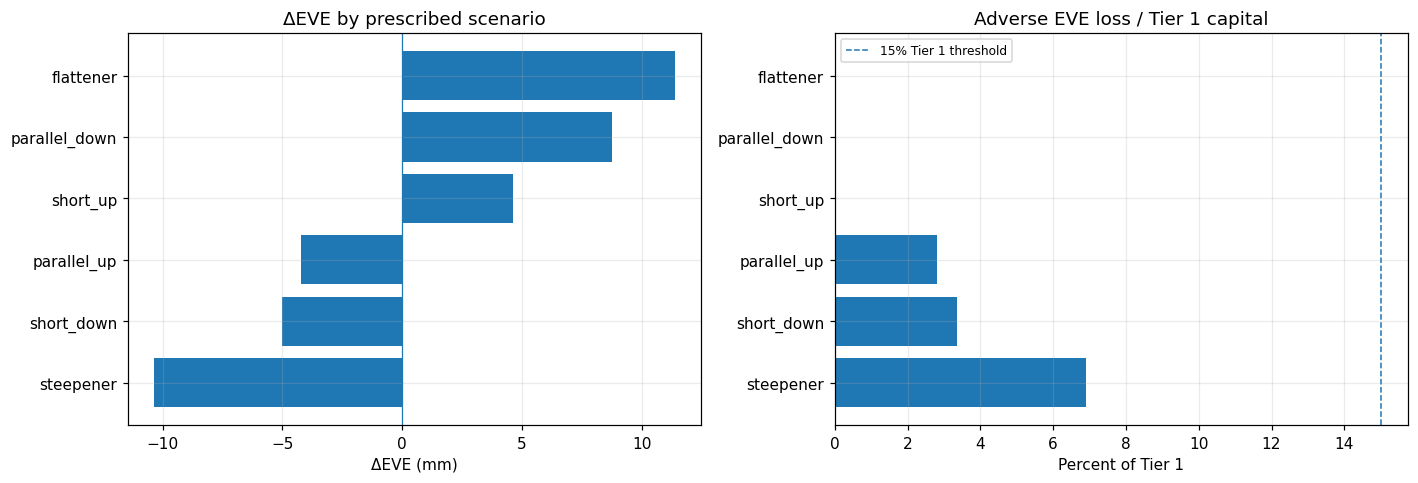

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

plot_table = irrbb_table.sort_values("delta_EVE_mm")
axes[0].barh(plot_table.index, plot_table["delta_EVE_mm"])
axes[0].axvline(0.0, linewidth=0.8)
axes[0].set_title("ΔEVE by prescribed scenario")
axes[0].set_xlabel("ΔEVE (mm)")

axes[1].barh(plot_table.index, plot_table["adverse_delta_EVE_to_Tier1_pct"])
axes[1].axvline(OUTLIER_LIMIT * 100.0, linestyle="--", linewidth=1.0, label="15% Tier 1 threshold")
axes[1].set_title("Adverse EVE loss / Tier 1 capital")
axes[1].set_xlabel("Percent of Tier 1")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Constant-balance-sheet 12-month ΔNII

The earnings model uses each row's next repricing date and an exposure period of:

$$
\max(1-\text{repricing time},0).
$$

Assets increase NII when rates rise; liabilities reduce NII. NMD customer rates reprice immediately but only partially through product-specific, asymmetric deposit betas. The model also prevents shocked customer/funding rates from falling below zero.

This remains a simplified first-order ΔNII model: it excludes commercial margins on replacement business, basis risk, optionality, volume changes and management actions.

In [11]:
def nii_contributions(book, shock_bp, horizon_y=NII_HORIZON_YEARS):
    shock_decimal = shock_bp / 10_000.0
    rows = []

    for _, row in book.iterrows():
        repricing_time = float(row["nii_repricing_y"])
        exposure_years = max(horizon_y - repricing_time, 0.0)
        beta = float(row["nii_beta_up"] if shock_bp >= 0 else row["nii_beta_down"])

        intended_rate_change = beta * shock_decimal
        base_rate = float(row["coupon_rate"])
        shocked_rate = max(base_rate + intended_rate_change, 0.0)
        actual_rate_change = shocked_rate - base_rate

        gross_interest_change = float(row["notional_mm"]) * actual_rate_change * exposure_years
        nii_sign = 1.0 if row["side"] == "asset" else -1.0
        contribution = nii_sign * gross_interest_change

        rows.append({
            "instrument_id": row["instrument_id"],
            "side": row["side"],
            "product": row["product"],
            "notional_mm": row["notional_mm"],
            "repricing_y": repricing_time,
            "exposure_y": exposure_years,
            "beta": beta,
            "actual_rate_change_bp": actual_rate_change * 10_000.0,
            "delta_NII_mm": contribution,
        })

    return pd.DataFrame(rows)


parallel_shock_bp = SHOCK_CONFIG_BP[CURRENCY]["parallel"]
nii_up_details = nii_contributions(banking_book, +parallel_shock_bp)
nii_down_details = nii_contributions(banking_book, -parallel_shock_bp)

nii_up_mm = nii_up_details["delta_NII_mm"].sum()
nii_down_mm = nii_down_details["delta_NII_mm"].sum()

print(f"12m ΔNII, parallel +{parallel_shock_bp:.0f} bp : {nii_up_mm:+,.2f} mm")
print(f"12m ΔNII, parallel -{parallel_shock_bp:.0f} bp : {nii_down_mm:+,.2f} mm")

nii_summary = pd.DataFrame({
    f"+{parallel_shock_bp:.0f}bp": nii_up_details.groupby(["side", "product"])["delta_NII_mm"].sum(),
    f"-{parallel_shock_bp:.0f}bp": nii_down_details.groupby(["side", "product"])["delta_NII_mm"].sum(),
}).fillna(0.0)
display(nii_summary)

print("Largest +shock contributions:")
display(nii_up_details.reindex(nii_up_details["delta_NII_mm"].abs().sort_values(ascending=False).index).head(10))

12m ΔNII, parallel +200 bp : +0.10 mm
12m ΔNII, parallel -200 bp : -2.05 mm


+200bp  -200bp
side      product                             
asset     Corporate fixed        0.000    0.00
          Corporate floating     3.000   -3.00
          HQLA floating          1.500   -1.50
          Mortgage fixed         0.000    0.00
          Mortgage floating      1.500   -1.50
          Retail floating        2.500   -2.50
          SME floating           1.500   -1.50
          Securities fixed       0.000    0.00
liability Money-market funding  -1.800    1.80
          NMD core ladder       -4.095    2.34
          NMD non-core          -0.455    0.26
          Term funding fixed     0.000    0.00
          Wholesale floating    -3.550    3.55

Largest +shock contributions:


,instrument_id,side,product,notional_mm,repricing_y,exposure_y,beta,actual_rate_change_bp,delta_NII_mm
1,A02,asset,Corporate floating,200.0,0.25,0.75,1.00,200.0,3.000
3,A04,asset,Retail floating,250.0,0.50,0.50,1.00,200.0,2.500
9,L02,liability,Wholesale floating,150.0,0.25,0.75,1.00,200.0,-2.250
8,L01,liability,Money-market funding,120.0,0.25,0.75,1.00,200.0,-1.800
0,A01,asset,HQLA floating,100.0,0.25,0.75,1.00,200.0,1.500
2,A03,asset,SME floating,150.0,0.50,0.50,1.00,200.0,1.500
4,A05,asset,Mortgage floating,300.0,0.75,0.25,1.00,200.0,1.500
10,L03,liability,Wholesale floating,130.0,0.50,0.50,1.00,200.0,-1.300
15,NMD01,liability,NMD core ladder,117.0,0.00,1.00,0.35,70.0,-0.819
16,NMD02,liability,NMD core ladder,117.0,0.00,1.00,0.35,70.0,-0.819


## 9. Validation checks

These checks do not replace model validation, but they catch the unit, sign and integration failures that commonly appear in notebook prototypes.

In [12]:
# Data and curve checks
assert zero_yields.index.is_monotonic_increasing
assert zero_yields.notna().all().all()
assert np.isfinite(fitted_values).all()
assert lambda1_hat > 0.0
assert design_condition < 100_000

# Balance-sheet and NMD integration checks
assert np.isclose(book_assets_mm, book_liabilities_mm + TIER1_CAPITAL_MM)
assert np.isclose(
    banking_book.loc[banking_book["product"].str.startswith("NMD"), "notional_mm"].sum(),
    CURRENT_NMD_MM,
)
assert (base_valuation["details"]["pv_mm"] > 0).all()
assert EVE_BASE_MM > 0

# Shock-unit and shape checks
probe = np.array([0.25, 30.0])
assert np.allclose(irrbb_shift_bp(probe, "parallel_up"), SHOCK_CONFIG_BP[CURRENCY]["parallel"])
assert np.allclose(irrbb_shift_bp(probe, "parallel_down"), -SHOCK_CONFIG_BP[CURRENCY]["parallel"])
steepener_probe = irrbb_shift_bp(probe, "steepener")
assert steepener_probe[0] < steepener_probe[1]  # short end down relative to long end
assert np.isfinite(irrbb_table.select_dtypes(include=[np.number]).values).all()

# EVE and NII checks
assert np.isfinite([EVE_BASE_MM, effective_duration_eve, effective_convexity_eve]).all()
assert np.isclose(nii_up_details["delta_NII_mm"].sum(), nii_up_mm)
assert np.isclose(nii_down_details["delta_NII_mm"].sum(), nii_down_mm)
assert parallel_shock_bp == 200.0 if CURRENCY == "USD" else True

# Design collinearity check: with a single decay parameter, the design matrix
# should be dramatically better conditioned than the old 4-parameter Svensson
# fit (which had condition number ~341 at its fitted lambda2 ~15.5y).
assert design_condition < 341.0, "Expected the reduced 3-parameter design to be better conditioned."

print("All validation checks passed.")


All validation checks passed.


## 10. Optional appendix — DV01-neutral 2s10s diagnostic

This section is intentionally separated from the IRRBB engine. A **steepener** is defined as long the 2-year zero-coupon bond and short the 10-year zero-coupon bond with matched DV01. To first order, its P&L per unit DV01 is:


$$
\Delta y_{10Y}-\Delta y_{2Y}.
$$

The holding-period carry/roll signal is computed from exact zero-coupon price ratios under an unchanged curve. Realised P&L is reported in **basis points per unit DV01**, with a simple turnover cost. When the input panel is synthetic, the result is only a code-path diagnostic and carries no empirical trading claim.

Data source                      : Federal Reserve GSW SVENY zero-coupon curve (live)
Annualised Sharpe after toy cost : -0.04
Maximum drawdown                 : -93.84 bp per unit DV01
Time in market                   : 76.8%


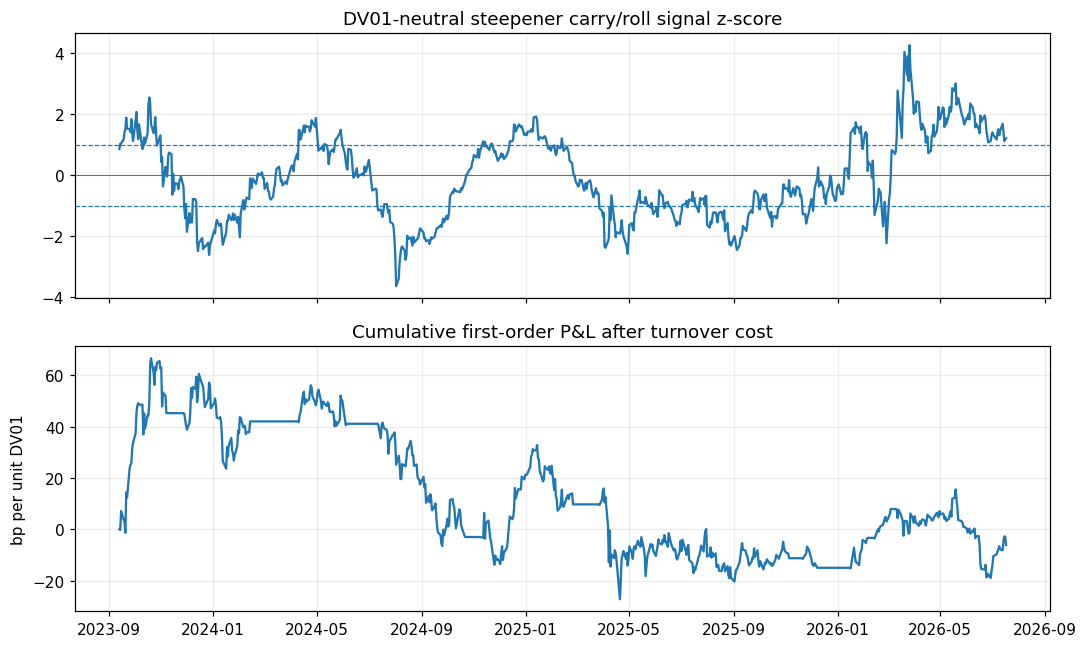

In [13]:
def zero_coupon_price(beta, maturity_y):
    rate_decimal = float(nss_zero_rate_pct(beta, maturity_y, lambda1_hat)[0]) / 100.0
    return np.exp(-rate_decimal * maturity_y)


def zero_coupon_holding_return(beta, maturity_y, holding_y=1.0/12.0):
    if maturity_y <= holding_y:
        raise ValueError("Maturity must exceed the holding period.")
    p0 = zero_coupon_price(beta, maturity_y)
    p1 = zero_coupon_price(beta, maturity_y - holding_y)
    return p1 / p0 - 1.0


def dv01_zero_coupon(beta, maturity_y):
    price = zero_coupon_price(beta, maturity_y)
    return maturity_y * price * 1e-4


carry_roll_signal_bp = []
for _, row in nss_params.iterrows():
    beta = row[["beta0", "beta1", "beta2"]].values
    p2 = zero_coupon_price(beta, 2.0)
    p10 = zero_coupon_price(beta, 10.0)
    dv01_2 = dv01_zero_coupon(beta, 2.0)
    dv01_10 = dv01_zero_coupon(beta, 10.0)
    short_10y_face = dv01_2 / dv01_10

    pnl_price = (
        p2 * zero_coupon_holding_return(beta, 2.0)
        - short_10y_face * p10 * zero_coupon_holding_return(beta, 10.0)
    )
    carry_roll_signal_bp.append(pnl_price / dv01_2)

carry_roll_signal_bp = pd.Series(
    carry_roll_signal_bp, index=nss_params.index, name="steepener_carry_roll_bp_per_dv01"
)
rolling_mean = carry_roll_signal_bp.rolling(126, min_periods=42).mean()
rolling_std = carry_roll_signal_bp.rolling(126, min_periods=42).std()
signal_z = ((carry_roll_signal_bp - rolling_mean) / rolling_std).dropna()

ENTRY_Z, EXIT_Z = 1.0, 0.25
position = pd.Series(0.0, index=signal_z.index)
current_position = 0.0
for date, z_value in signal_z.items():
    if current_position == 0.0 and z_value > ENTRY_Z:
        current_position = 1.0   # DV01-neutral steepener
    elif current_position == 0.0 and z_value < -ENTRY_Z:
        current_position = -1.0  # DV01-neutral flattener
    elif current_position != 0.0 and abs(z_value) < EXIT_Z:
        current_position = 0.0
    position.loc[date] = current_position

slope_bp = (zero_yields["10Y"] - zero_yields["2Y"]) * 100.0
first_order_pnl_bp = position.shift(1).fillna(0.0) * slope_bp.diff().reindex(position.index)
turnover = position.diff().abs().fillna(position.abs())
transaction_cost_bp = 0.25 * turnover
strategy_pnl_bp = (first_order_pnl_bp - transaction_cost_bp).dropna()
cumulative_pnl_bp = strategy_pnl_bp.cumsum()

annualized_sharpe = (
    strategy_pnl_bp.mean() / strategy_pnl_bp.std() * np.sqrt(252)
    if strategy_pnl_bp.std() > 0 else np.nan
)
max_drawdown_bp = (cumulative_pnl_bp - cumulative_pnl_bp.cummax()).min()

print(f"Data source                      : {DATA_SOURCE}")
print(f"Annualised Sharpe after toy cost : {annualized_sharpe:.2f}")
print(f"Maximum drawdown                 : {max_drawdown_bp:.2f} bp per unit DV01")
print(f"Time in market                   : {(position != 0).mean():.1%}")
if DATA_SOURCE.startswith("SYNTHETIC"):
    print("SYNTHETIC DATA: the performance statistic is a pipeline diagnostic, not evidence of tradability.")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(signal_z.index, signal_z)
axes[0].axhline(ENTRY_Z, linestyle="--", linewidth=0.8)
axes[0].axhline(-ENTRY_Z, linestyle="--", linewidth=0.8)
axes[0].axhline(0.0, linewidth=0.6)
axes[0].set_title("DV01-neutral steepener carry/roll signal z-score")

axes[1].plot(cumulative_pnl_bp.index, cumulative_pnl_bp)
axes[1].set_title("Cumulative first-order P&L after turnover cost")
axes[1].set_ylabel("bp per unit DV01")
plt.tight_layout()
plt.show()


## 11. Interpretation and remaining limitations

### What is now internally coherent

- Valuation uses continuously compounded **zero-coupon** rates rather than treating constant-maturity yields as zero rates.
- Curve shape parameters use a classic 3-parameter Nelson-Siegel (single decay lambda), estimated globally rather than day-by-day, and deliberately reduced from the original 4-parameter Nelson-Siegel-Svensson form after diagnosing severe collinearity between the slope and second curvature regressors at the fitted Svensson lambda2 (condition number ~341 vs the ~40-50 typical of a well-identified 3-parameter fit on this tenor grid).
- The NMD replicating portfolio is part of the liability book used in **both EVE and NII**.
- Assets, interest-bearing liabilities and Tier 1 capital reconcile exactly.
- The six scenarios use the **2026 BCBS shock table** and report the supervisory **adverse ΔEVE / Tier 1** metric.
- The NII output uses the correct `+200 bp` unit for USD and attributes impacts instrument by instrument.
- The curve-trade appendix uses a defined DV01-neutral steepener sign convention and reports P&L in basis points.

### What remains illustrative

- The balance sheet, coupon rates, NMD history, core split, deposit betas and Tier 1 amount are synthetic assumptions.
- No account-level behavioural calibration, prepayment model, early-redemption model, embedded option model, basis-risk model or multicurrency aggregation is included.
- Floating-rate EVE treatment uses a par-at-next-reset approximation.
- The NII engine is first-order and assumes a constant balance sheet; it does not model new-business margins or management actions.
- Production deployment would require versioned market data, model governance, independent validation, audit trails, scenario approval, unit tests, access controls and regulatory/jurisdictional configuration.

Accordingly, the correct portfolio description is **“Prototype IRRBB and ALM Analytics Engine”**, not a production regulatory engine.